# RadarScenes MLP Classifier: Findings Report (v1.0)

5 class point cloud radar object classifier (`car`, `large_vehicle`, `two_wheeler`, `pedestrian`, `pedestrian_group`) trained on [RadarScenes](https://radar-scenes.com/). In depth writeup: what limits accuracy, what fixes it, whether the split methodology can be trusted, and why the taxonomy is shaped the way it is. Findings below are numbered by rank (Summary style, matching `MLP_Decisions_and_Findings.md`); every other section is supporting context, not part of that ranking. Full raw experimental log: `MLP_Decisions_and_Findings.md` (23 sections), `mlp_ablations.ipynb`. A 1 page version for a quick scan: `MLP_Showcase.md`.

## Setup

- **Classes**: `car`, `large_vehicle`, `two_wheeler`, `pedestrian`, `pedestrian_group`.
- **Features**: per instance histogram encoding. `rcs`, `vr_compensated`, `x_rel`, `y_rel` each binned into 16 fraction of points bins, plus `doppler_spread` unbinned. 65 dims total. Encoding approach follows Tatarchenko and Rambach, "Histogram-based Deep Learning for Automotive Radar" (arXiv:2303.02975, 2023): point cloud histogram passed through an MLP.
- **Sensor**: [RadarScenes](https://radar-scenes.com/) (Schumann et al., arXiv:2104.02493, 2021) records 4 automotive radar sensors mounted on the front bumper, sensors 1/4 at &plusmn;85&deg; and sensors 2/3 at &plusmn;25&deg; from the driving direction. This project uses sensor 2 (front right, +25&deg;) only, the dataset's own default single sensor choice. Layout diagram under On the data.
- **Model**: 3 layer MLP, 2 hidden layers of 16 units, ReLU.
- **Data**: fixed sequence grouped train/val/test split.
- **Noise floor**: 6 fold split sensitivity check (`split_sensitivity.py`), same 70/15/15 proportions, sequences reassigned. Macro F1 range 0.651 to 0.734 (std 0.027) on baseline config alone. Every result below is evaluated against this range, not a single run.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from build_points_table import build_and_save_points_table
from taxonomy_separability import add_relative_features
from mlp_classifier import apply_mlp_class_groups

df = build_and_save_points_table()
df = add_relative_features(df)
df = apply_mlp_class_groups(df)
df["group"].value_counts()

/home/bruno/radar_machine_learning_ws/results/data/points_table.parquet already covers exactly the requested sequences, skipping build


group
car                 556288
pedestrian_group    366304
large_vehicle       284591
pedestrian          137044
two_wheeler          91088
Name: count, dtype: int64

## Confusion matrix

/home/bruno/radar_machine_learning_ws/results/mlp/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.937   0.784  0.854    31055
large_vehicle         0.719   0.797  0.756     6247
two_wheeler           0.475   0.545  0.508     4629
pedestrian            0.534   0.944  0.682    11325
pedestrian_group      0.754   0.544  0.632    17858


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_confusion_matrix.png
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_precision_recall_f1.png


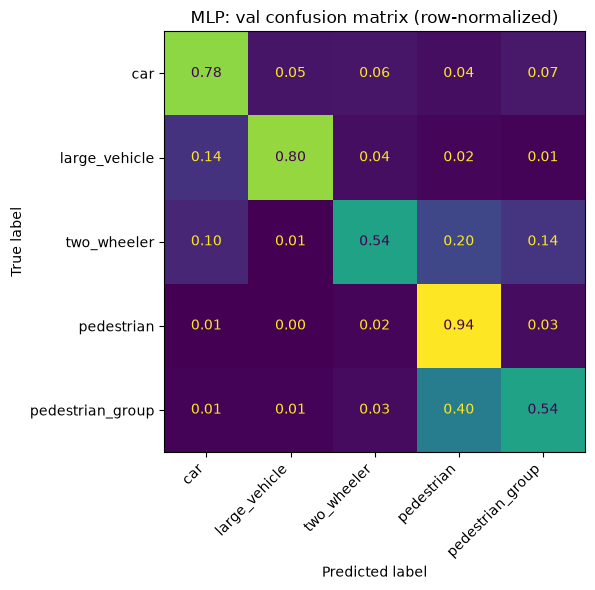

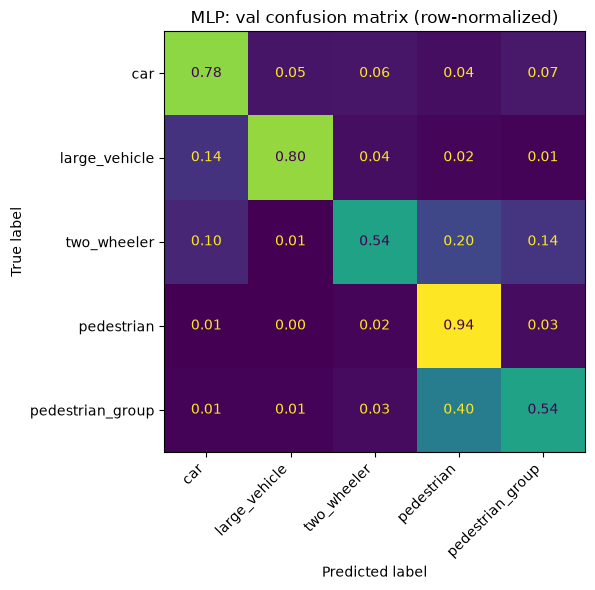

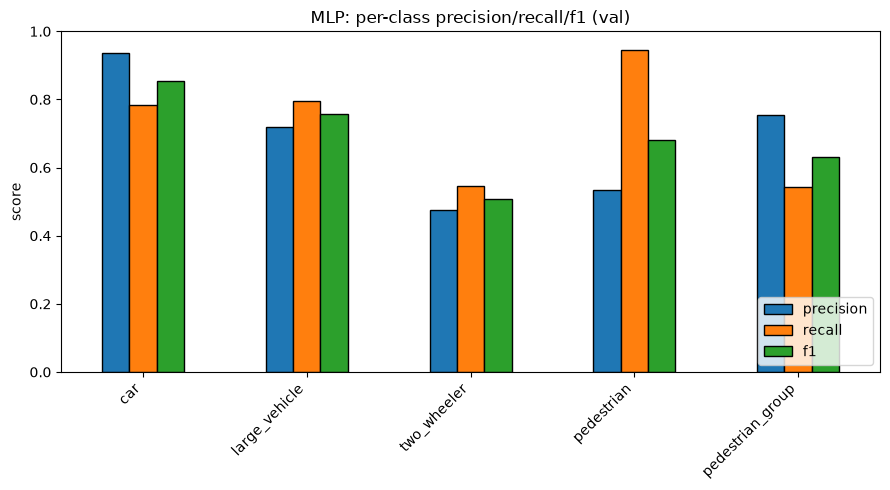

In [2]:
from mlp_classifier import evaluate_val_metrics

# loads the cached baseline model, no retraining
val_metrics_df, cm_fig, _ = evaluate_val_metrics(df)
cm_fig

Row normalized, val set, cached baseline model. `car` and `pedestrian` are the strongest classes, `two_wheeler` the weakest. Mechanisms behind each class's errors: findings 1 and 3 below, synthesized per class at the end.

## Finding 1: sparsity is the primary performance ceiling

- Method: bucket the already trained baseline model's val predictions by instance point count (`evaluate_by_point_count`), no retraining, compared against 10 independently retrained model/feature variants.

| variant | what changed |
|---|---|
| `hidden8` / `hidden32` / `hidden64` | `hidden_dim` in {8, 32, 64} vs baseline 16 |
| `deep10` | depth 10 layers vs baseline 2 (with batch norm) |
| `range_sc` | `range_sc` in place of `doppler_spread` |
| `azimuth_extent` | `azimuth_extent` added |
| `spatial_extent` | `spatial_extent` in place of `x_rel`/`y_rel` |
| `n_points` | `n_points` added as extra scalar |
| `raw_counts` | raw bin counts in place of fractions |
| `stat_descriptors` | explicit per instance statistics (mean/median/std of `rcs`, `vr_compensated`, `radial`, `azimuth_sc`, `doppler_spread`) in place of histograms |
| `gaussian_range` / `quantile_bins` | gaussian range / quantile based bin edges |
| `rcs_extent_only` | `rcs_extent` added alone |
| `spatial_extent_added` | `spatial_extent` added alongside `x_rel`/`y_rel` |
| `no_vr_compensated` | `vr_compensated` removed |

All null, every result inside the noise floor above.

In [3]:
from mlp_classifier import evaluate_by_point_count, format_point_count_deltas, plot_point_count_curve

# loads the cached baseline model, buckets its own val predictions - no retraining
point_count_summary = evaluate_by_point_count(df)
format_point_count_deltas(point_count_summary)

            n  accuracy  macro_f1  f1_car  f1_large_vehicle  f1_two_wheeler  f1_pedestrian  f1_pedestrian_group  support_car  support_large_vehicle  support_two_wheeler  support_pedestrian  support_pedestrian_group
bucket                                                                                                                                                                                                                
1       24004     0.619     0.381   0.839             0.037           0.389          0.641                0.000        10295                    656                 1391                6318                      5344
2       17353     0.741     0.606   0.856             0.237           0.516          0.747                0.673         8287                    467                 1281                3117                      4201
3       11711     0.800     0.702   0.881             0.471           0.597          0.770                0.791         5923                

,n,support_car,support_large_vehicle,support_two_wheeler,support_pedestrian,support_pedestrian_group,accuracy,macro_f1,f1_car,f1_large_vehicle,f1_two_wheeler,f1_pedestrian,f1_pedestrian_group
bucket,,,,,,,,,,,,,
1,24004,10295,656,1391,6318,5344,0.619,0.381,0.839,0.037,0.389,0.641,0.000
2,17353,8287,467,1281,3117,4201,0.741 (+0.122),0.606 (+0.224),0.856 (+0.017),0.237 (+0.200),0.516 (+0.127),0.747 (+0.105),0.673 (+0.673)
3,11711,5923,412,927,1277,3172,0.800 (+0.181),0.702 (+0.321),0.881 (+0.042),0.471 (+0.433),0.597 (+0.208),0.770 (+0.129),0.791 (+0.791)
4,6567,3156,399,497,447,2068,0.821 (+0.202),0.762 (+0.380),0.878 (+0.039),0.687 (+0.650),0.652 (+0.263),0.768 (+0.127),0.823 (+0.823)
5,3507,1427,452,287,117,1224,0.815 (+0.196),0.764 (+0.383),0.847 (+0.008),0.833 (+0.796),0.658 (+0.270),0.652 (+0.010),0.830 (+0.830)
6-10,6348,1679,2651,242,49,1727,0.854 (+0.236),0.715 (+0.334),0.798 (-0.041),0.963 (+0.926),0.525 (+0.136),0.476 (-0.165),0.813 (+0.813)
11+,1624,288,1210,4,0,122,0.929 (+0.310),0.538 (+0.156),0.822 (-0.017),0.995 (+0.958),0.211 (-0.178),0.000 (-0.641),0.660 (+0.660)


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_point_count_curve.png


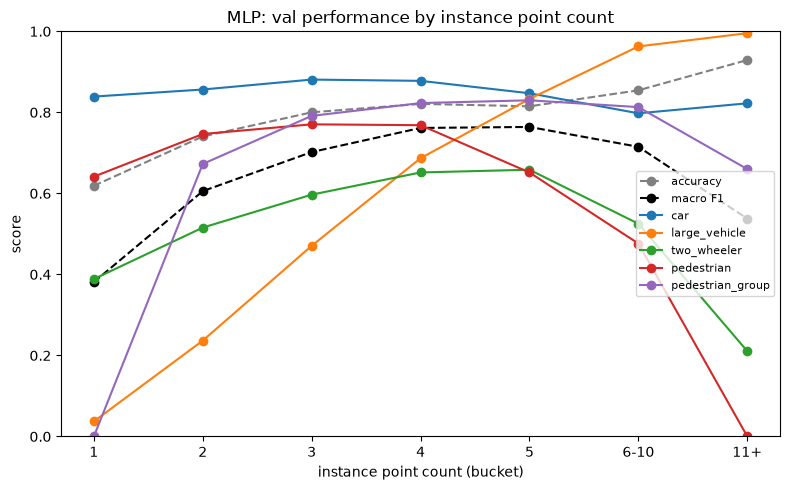

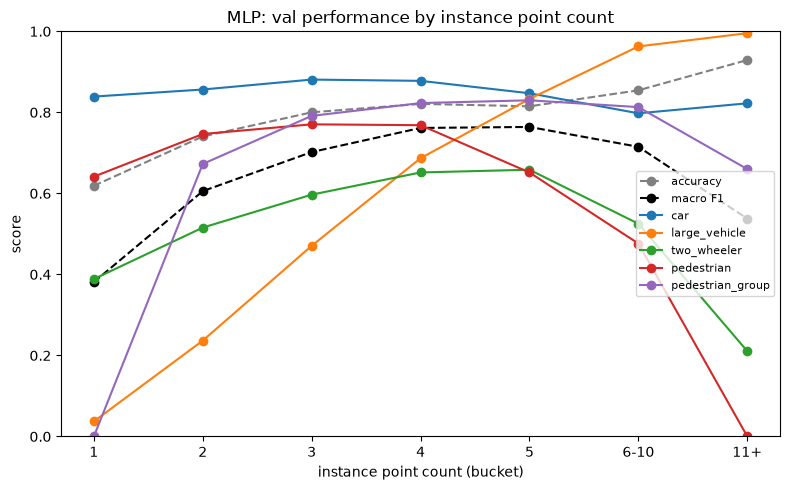

In [4]:
plot_point_count_curve(point_count_summary)

- Macro F1: 0.381 at 1 point/instance, 0.764 at 5 points/instance. Same trained model, point count is the only variable.
- `large_vehicle`: F1 0.037 at n=1, 0.995 at n=11+ (62% of val instances have 6+ points). Size is not determinable from a single point.
- `car`: F1 flat at 0.80 to 0.88 across all point counts. RCS and Doppler alone separate it at n=1.
- Conclusion: additional points aggregated per instance (multi scan, multi sensor) address the ceiling directly. Feature or capacity changes at fixed point count do not.

Worth calling out separately: `stat_descriptors` (explicit per instance statistics, mean/median/std, replacing the 65 dim histogram encoding entirely) is the one variant above that did not just land flat. Macro F1 0.658 vs baseline's 0.686, inside the overall noise floor but only barely, and `pedestrian`'s own f1 dropped outside its class specific noise floor (-0.075 vs a spread of 0.073), the only such case across every variant tested. Why it did not help: histograms and explicit statistics are just two different summaries of the same limited raw points, and the ceiling above is upstream of that choice, how many real points an instance has to begin with, not how those points get encoded. Removing the histogram's binning step entirely and still landing at the same ceiling is itself evidence for that, not against the histogram encoding specifically.

## Finding 2: one validated positive result, combined_features

- Every variant in finding 1's table, tested in isolation, fell inside the noise floor.
- Method: `combined_features` stacks all of them additively onto baseline (102 dims vs 65, nothing removed), evaluated via the same 6 fold split sensitivity procedure, paired fold by fold against baseline (sign test for a non chance win rate).

/home/bruno/radar_machine_learning_ws/results/mlp/combined_features/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/combined_features/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/combined_features/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.947   0.794  0.864    31055
large_vehicle         0.668   0.819  0.736     6247
two_wheeler           0.510   0.666  0.578     4629
pedestrian            0.588   0.823  0.686    11325
pedestrian_group      0.752   0.653  0.699    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/combined_features/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/combined_features/mlp_precision_recall_f1.png


,precision,recall,f1,support
car,0.946932,0.794075,0.863793,31055
large_vehicle,0.668015,0.819433,0.736017,6247
two_wheeler,0.510268,0.665587,0.577669,4629
pedestrian,0.587568,0.822958,0.685622,11325
pedestrian_group,0.752273,0.653321,0.699314,17858


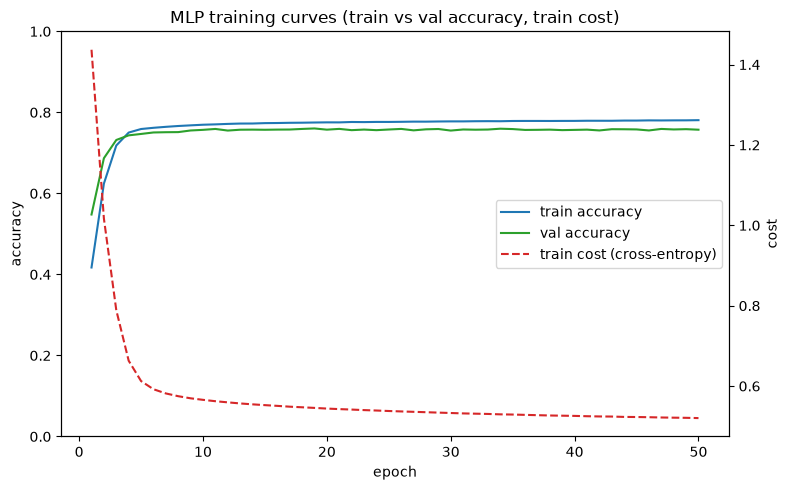

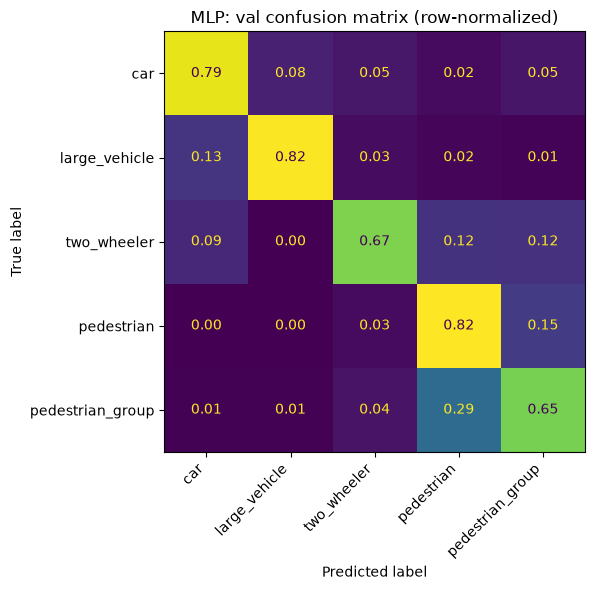

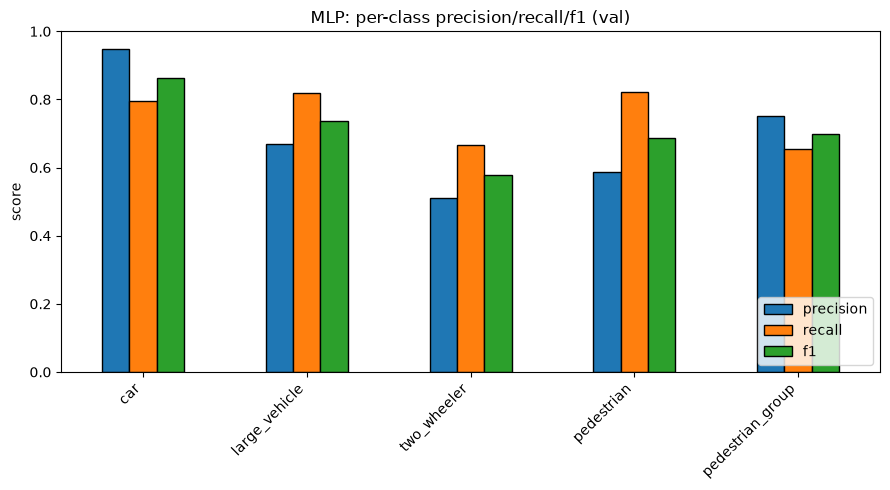

In [5]:
from mlp_variants import run_variant

# loads the cached combined_features model - no retraining
model, history, metrics_df, cm_fig, bar_fig = run_variant(df, "combined_features")
metrics_df

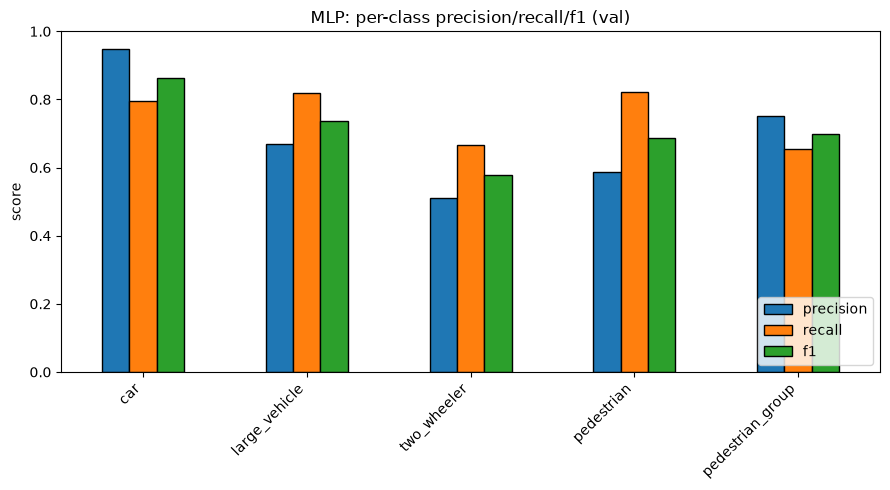

In [6]:
bar_fig

Evaluated across the same 6 splits used for the noise floor, paired fold by fold against baseline:

| fold | baseline F1 | combined_features F1 | delta |
|---|---|---|---|
| 0 | 0.679 | 0.708 | +0.029 |
| 1 | 0.734 | 0.775 | +0.041 |
| 2 | 0.701 | 0.738 | +0.037 |
| 3 | 0.651 | 0.701 | +0.050 |
| 4 | 0.695 | 0.734 | +0.039 |
| 5 | 0.688 | 0.706 | +0.018 |

- Wins 6/6 folds, mean delta +0.036 macro F1. P(6/6 by chance, assuming equivalence) approx 1.6%.
- Gain concentrated in `two_wheeler` and `pedestrian_group`. `large_vehicle` (finding 1's sparsity casualty) shows no gain.
- Magnitude: approximately 1/10 of finding 1's effect size. Independent, additive signal, not a reduction of the sparsity ceiling.

## Finding 3: sequence level correlation inflates apparent split variance

- `StratifiedGroupKFold` matches instance count ratios per split but cannot split a sequence. A class whose instance count is concentrated in few sequences has its val distribution set by which of those sequences are assigned to val, independent of the overall ratio.
- Mechanism, traced for `two_wheeler` (largest fold to fold F1 spread in the project, 0.386): a single tracked object detected across many consecutive scans (e.g. a stationary or idling cyclist) generates hundreds of correlated instances under one sequence.
- Method: pairwise KS statistic computed between every pair of the 6 split sensitivity folds' per instance feature distributions (`rcs`, `vr_compensated`, `x_rel`, `y_rel`, `spatial_extent`, `doppler_spread`). Causal claim confirmed by retraining baseline with `vr_compensated` removed, across the same 6 folds. Different question from the confusion mechanism below: not why `two_wheeler` is confused with `pedestrian`, why its score varies fold to fold regardless of confusion target.

![two_wheeler vr_compensated distribution across the 6 splits](../results/fold_stability/two_wheeler_vr_compensated_by_fold.png)

- `vr_compensated`, the model's highest weighted feature (zero out importance drop -0.331, next highest -0.080), shows the largest cross fold KS statistic for `two_wheeler` (mean 0.370). Its instability propagates directly into F1 instability.
- Causal check: retraining without `vr_compensated` narrows `two_wheeler`'s fold to fold F1 spread from 0.386 to 0.133.

## Per class error mechanism

Per class view of how findings 1 and 3 actually show up in the confusion matrix above. Method: separability probes (logistic regression + random forest, sparse n<=2 vs dense n>=5 point regimes), two sample Kolmogorov-Smirnov (KS) test per raw feature, grouped permutation importance on the histogram encoding, softmax confidence margin on real predictions, and zero out ablation importance on the combined_features model (section 14a of the full log). No additional model retrained for this section.

**`car` -> `large_vehicle`** (73% correct, 10% predicted `large_vehicle`):

| regime | probe AUC | dominant KS feature | KS value | real confusion rate |
|---|---|---|---|---|
| sparse (n<=2) | 0.61 | `rcs` | 0.125 | 5.3% |
| dense (n>=5) | 0.98 | `x_rel` | 0.277 | 9.2% |

Dense is far more separable by probe AUC but shows the higher real error rate. Not explained by the top KS feature itself: misclassified cars carry roughly half the decision margin of confident calls (median softmax margin 0.15 to 0.30 vs 0.47 to 1.0), and are anomalously wide relative to their own class (`y_extent`/`spatial_extent` elevated toward `large_vehicle` scale). Sparse regime overlap is genuine, misclassified car `rcs` sits at car's own upper tail, reaching into `large_vehicle`'s typical range.

**`large_vehicle`**: covered under finding 1, sparsity ceiling, not a separability or confidence issue.

**`two_wheeler` <-> `pedestrian`** (`two_wheeler`'s lowest recall of any class):

| metric | value |
|---|---|
| `two_wheeler` predicted as `pedestrian` | 20 to 24% |
| `pedestrian` predicted as `two_wheeler` | 1 to 2% |
| `vr_compensated` zero out F1 drop | -0.331 |
| next highest feature drop (`spatial_extent`) | -0.080 |
| local density ratio, pedestrian:two_wheeler at `vr_compensated` approx 0, sparse | approx 12:1 |
| same ratio, dense | approx 1:1 |

`vr_compensated` dominates the model but reads near zero for both a stationary pedestrian and an idling or tangentially moving `two_wheeler`. Local instance density at that value favors `pedestrian` roughly 12:1 in sparse, so a true `two_wheeler` there is outvoted. Confusion is one directional since `pedestrian` has near zero mass in `two_wheeler`'s higher speed range. Same feature as finding 3, different question: there it explains cross fold score variance, here it explains the confusion itself.

**`pedestrian`**: highest recall of any class (0.886 val, 0.928 test), the direct counterpart of the row above. Residual confusion is with `pedestrian_group` at high point count, not with `car` or `two_wheeler`.

## Confirmation: held out test set

- Method: `evaluate_test_metrics` on the cached baseline model, computed once, after all tuning concluded. Test set untouched through every prior training, tuning, and ablation step.

/home/bruno/radar_machine_learning_ws/results/mlp/mlp_test_metrics.json already cached, reusing
per-class precision/recall/f1 (test):
                  precision  recall     f1  support
car                   0.943   0.821  0.877    29958
large_vehicle         0.740   0.793  0.766     6103
two_wheeler           0.511   0.637  0.567     4879
pedestrian            0.533   0.928  0.677    11363
pedestrian_group      0.775   0.500  0.608    17420
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_test_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_test_precision_recall_f1.png


,val_f1,test_f1,val_recall,test_recall
car,0.854,0.877,0.784,0.821
large_vehicle,0.756,0.766,0.797,0.793
two_wheeler,0.508,0.567,0.545,0.637
pedestrian,0.682,0.677,0.944,0.928
pedestrian_group,0.632,0.608,0.544,0.500
macro_avg,0.686,0.699,0.723,0.736


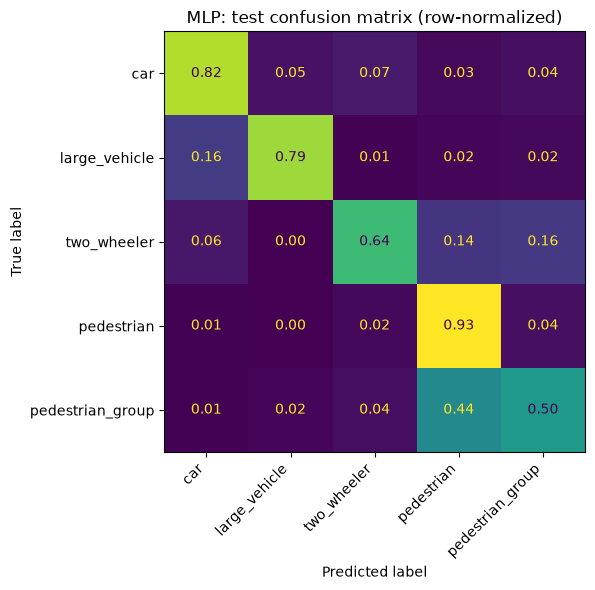

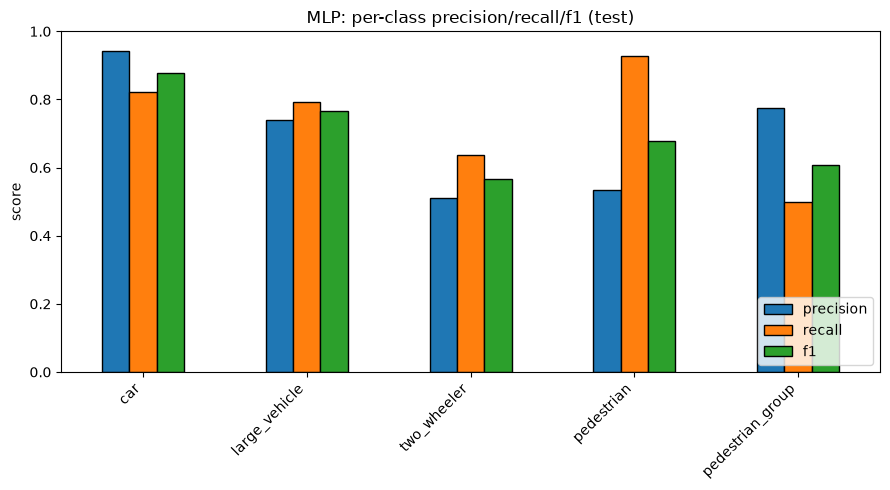

In [7]:
import pandas as pd
from mlp_classifier import evaluate_test_metrics

# loads the cached baseline model, evaluates on test - the one and only time this project touches it
test_metrics_df, test_cm_fig, _ = evaluate_test_metrics(df)
val_metrics = pd.read_json("../results/mlp/mlp_val_metrics.json", orient="index")
comparison = pd.DataFrame({
    "val_f1": val_metrics["f1"], "test_f1": test_metrics_df["f1"],
    "val_recall": val_metrics["recall"], "test_recall": test_metrics_df["recall"],
})
comparison.loc["macro_avg"] = comparison.mean()
comparison.round(3)

- Test macro F1: 0.699. Val macro F1: 0.686. Delta +0.013, inside the 0.651 to 0.734 noise floor.
- No overfitting detected. `two_wheeler` shows the largest val to test delta, consistent with its fold to fold instability (finding 3).

## On the data

![RadarScenes sensor layout, sensor 2 highlighted](../results/radarscenes_sensor_layout.png)

![Class distribution, final taxonomy](../results/class_imbalance/class_counts_merged.png)

- Root cause behind findings 1 and 3 is the same: RadarScenes is a naturalistically collected, fixed dataset. Common classes get broad incidental coverage, rare classes and rare subtypes do not. No amount of splitting or modeling fixes thin coverage that was never collected. `car` and `pedestrian_group` alone make up most of train, `two_wheeler` is the smallest of the five final classes.
- `large_vehicle` groups `large_vehicle`, `truck`, `train`, and (after a later revisit) `bus`, following RadarScenes' own recommended `ClassificationLabel` scheme, not an ad hoc merge. Two reasons forced it: `train` has only 57 raw instances, all inside one sequence, impossible to split into train/val without leakage; a held out probe found `large_vehicle`/`truck` pairwise separability near chance (AUC 0.632, 74% confused as each other), confirmed at proper cross validation (`large_vehicle` alone: precision 0.24, recall 0.29, barely usable, only 23 of 158 sequences ever contain one). `bus` was initially kept separate on mixed evidence, but the real MLP's confusion matrix later showed it heavily confused with `large_vehicle` anyway, merging raised the combined class's F1 to 0.756, above either `bus` (0.543) or `large_vehicle` (0.492) alone.
- `two_wheeler`'s instability (finding 3) has a second contributing factor beyond sequence concentration: it merges two physically different velocity regimes (`bicycle`, `motorized_two_wheeler`, the latter only 4.7% of `two_wheeler` instances), a taxonomy simplification, not a data defect. Mixed evidence on how much this specifically drives the instability, sequence concentration through `vr_compensated` (finding 3) remains the better supported explanation.
- Practical read: `two_wheeler` does not need a better model, it needs more independent sequences and richer point counts per instance for that specific class. Findings 1 and 3 are two symptoms of the same underlying data gap, not separate problems.

## Next step

- Finding 1 (sparsity) is the largest unaddressed lever. Direction: aggregate a tracked object's points across multiple scans instead of classifying single scan instances independently. Attacks sparsity at the input level rather than the encoding. Untested, proposed as v1.1.

## Full writeup

`MLP_Decisions_and_Findings.md` (23 sections, full ablation and mechanism trace, raw log) and `mlp_ablations.ipynb` (executed ablation program) for maximum depth. `MLP_Showcase.md` for a 1 page version. This notebook and `MLP_Report.md` sit in between.

## References

O. Schumann et al., "RadarScenes: A Real-World Radar Point Cloud Data Set for Automotive Applications," arXiv:2104.02493, 2021. [https://arxiv.org/abs/2104.02493](https://arxiv.org/abs/2104.02493)

M. Tatarchenko and K. Rambach, "Histogram-based Deep Learning for Automotive Radar," arXiv:2303.02975, 2023. [https://arxiv.org/abs/2303.02975](https://arxiv.org/abs/2303.02975)